In [ ]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import yaml
import random
import numpy as np
import pandas as pd
from pprint import pprint
from pathlib import Path
from matplotlib import pyplot as plt

import torch
from torchinfo import summary
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from modules.datamodule import LungSoundDataModule
from modules.classifier import LungSoundClassifier
from modules.transforms import *

In [2]:
PROJECT_ROOT = Path(os.path.dirname(os.getcwd()))
DATA_FOLDER = PROJECT_ROOT / "data" / "preprocessed"
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

EXPERIMENTS_FOLDER = PROJECT_ROOT / "experiments"
if not os.path.exists(EXPERIMENTS_FOLDER):
    print(f"Experiments directory not found at {EXPERIMENTS_FOLDER}. Please ensure the experiment configuration files are placed in the correct location.")

LOGS_FOLDER = PROJECT_ROOT / "logs"
if not os.path.exists(LOGS_FOLDER):
    os.makedirs(LOGS_FOLDER)

CHECKPOINTS_FOLDER = PROJECT_ROOT / "checkpoints"
if not os.path.exists(CHECKPOINTS_FOLDER):
    os.makedirs(CHECKPOINTS_FOLDER)

RESULTS_FOLDER = PROJECT_ROOT / "results"
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

torch.set_float32_matmul_precision("high")
%load_ext tensorboard

Using device: cuda


In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_input_size(dm: LungSoundDataModule) -> tuple:
    """
    Get the input size for the model based on a sample batch from the DataModule.
    Args:
        dm (LungSoundDataModule): The DataModule to sample from.
    Returns:
        input_size (tuple): Tuple representing the shape of the input data (e.g., (B, C, H, W)).
    """
    dm.setup()
    loader = dm.train_dataloader()
    batch = next(iter(loader))
    inputs, _, _ = batch
    return tuple(inputs.shape)


def save_results(model) -> None:
    """
    Save test results to a CSV file.
    Args:
        test_results (dict): Dictionary containing test metrics and results.
        path (Path | str): Path to the CSV file where results will be saved.
    """
    classes = model.hparams.dataset["classes"]
    probs_df = pd.DataFrame(model.test_results["probs"], columns=[f"prob_{cls}" for cls in classes])
    results_df = pd.DataFrame({
        "target": model.test_results["targets"],
        "pred": model.test_results["preds"],
    })
    info_df = pd.DataFrame(model.test_results["info"])
    results_df = pd.concat([results_df, probs_df, info_df], axis=1)
    path = RESULTS_FOLDER / f"{model.hparams['experiment']}_results.csv"
    results_df.to_csv(path, index=False)
    print(f"Test results saved to {path}")


def train_model(hparams: dict, debug: bool = False) -> LungSoundClassifier:
    """
    Train a model.
    Args:
        hparams (dict): Hyperparameters and configuration for the experiment. Trainer parameters:
        ```
        - experiment (str): Name of the experiment for logging and checkpointing.
        - checkpoint_monitor (str): Metric to monitor for checkpointing (e.g., "val_loss").
        - checkpoint_mode (str): Mode for checkpointing ("min" or "max").
        - early_stop_monitor (str): Metric to monitor for early stopping (e.g., "val_loss").
        - early_stop_mode (str): Mode for early stopping ("min" or "max").
        - patience (int): Number of epochs with no improvement after which training will be stopped.
        - max_epochs (int): Maximum number of training epochs.
        - precision (int): Precision for training (e.g., 16 for mixed precision).
        ```
        debug (bool): If True, dry run the training for quick debugging. Default is False.
    Returns:
        model (LungSoundClassifier): The trained model.
    """
    set_seed(hparams["seed"])

    # Initialize logger
    logger = TensorBoardLogger(
        save_dir=LOGS_FOLDER,
        name=hparams["experiment"],
    )

    # Initialize callbacks
    callbacks = []
    if not debug:
        checkpoint_callback = ModelCheckpoint(
            dirpath=CHECKPOINTS_FOLDER,
            filename=hparams["experiment"] + "-{epoch}-{val_loss:.2f}-{val_f1_micro:.2f}-{val_f1_macro:.2f}",
            monitor=hparams["checkpoint_monitor"],
            mode=hparams["checkpoint_mode"],
            save_top_k=3,
            verbose=True,
        )
        callbacks.append(checkpoint_callback)

        early_stopping_callback = EarlyStopping(
            monitor=hparams["early_stop_monitor"],
            mode=hparams["early_stop_mode"],
            patience=hparams["patience"],
            verbose=True,
        )
        callbacks.append(early_stopping_callback)

    # Initialize DataModule and Model
    dm = LungSoundDataModule(hparams, DATA_FOLDER)
    model = LungSoundClassifier(hparams)

    # Display model architecture
    input_shape = get_input_size(dm)
    print("Model Summary:\n")
    print(f"Input shape: {input_shape}")
    print(summary(model, input_size=input_shape))
    print("\n")

    # Initialize Trainer
    trainer = Trainer(
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices="auto",
        max_epochs=hparams["max_epochs"],
        precision=hparams["precision"],
        callbacks=callbacks,
        logger=logger,
        fast_dev_run=debug,
    )

    # Train the model
    trainer.fit(model, dm)

    # Test the model
    trainer.test(model, dm)

    # Save test results to a CSV
    save_results(model)

    return model

In [4]:
def show_metrics(targets: np.ndarray, preds: np.ndarray, probs: np.ndarray, class_names: list):
    """
    Display classification metrics including classification report, ROC AUC curve, Precision-Recall curve, and confusion matrix.
    Args:
        targets (np.ndarray): Array of true target labels.
        preds (np.ndarray): Array of predicted labels by the model.
        probs (np.ndarray): Array of predicted probabilities for each class.
        class_names (list): List of class names corresponding to the target labels.
    """
    # y_true in one-hot encoding format for multi-class metrics
    y_true = label_binarize(targets, classes=np.arange(len(class_names)))

    # Print classification report
    print("Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))

    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        RocCurveDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("ROC Curves")
    plt.show()

    # Plot Precision-Recall curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        PrecisionRecallDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("Precision-Recall Curves")
    plt.show()

    # Plot confusion matrix
    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_model(model: LungSoundClassifier, test_model: bool = False):
    """
    Evaluate the model on the test set and display metrics.
    Args:
        model (LungSoundClassifier): The trained model to evaluate.
        test_model (bool): If True, run the test loop to populate test results.
    """
    hparams = model.hparams
    if not hasattr(model, "test_results") or test_model:
        dm = LungSoundDataModule(model.hparams, DATA_FOLDER)
        trainer = Trainer(
            accelerator="gpu" if DEVICE == "cuda" else "cpu",
            devices="auto",
            precision=model.hparams["precision"],
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
            enable_model_summary=False,
        )
        trainer.test(model, dm)

    targets = np.asarray(model.test_results["targets"])
    preds = np.asarray(model.test_results["preds"])
    probs = np.asarray(model.test_results["probs"])
    class_names = hparams.dataset["classes"]
    show_metrics(targets, preds, probs, class_names)

In [5]:
def load_hyperparameters(config_path: str) -> dict:
    """
    Load hyperparameters from a YAML configuration file.
    Args:
        config_path (str): Path to the YAML configuration file.
    Returns:
        hparams (dict): Dictionary containing the hyperparameters and configuration.
    """
    with open(config_path, "r") as file:
        hparams = yaml.safe_load(file)
    print("Experiment hyperparameters:")
    pprint(hparams)
    return hparams

## Inception V3 using STFT as features

In [6]:
experiment_file = EXPERIMENTS_FOLDER / "inception_v3" / "inception_v3_combined_8-classes_STFT.yaml"
hparams = load_hyperparameters(experiment_file)
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 32,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'STFT',
             'name': 'Combined_ICBHI_KAUH',
             'num_channels': 1},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'inception_v3_combined_8-classes_STFT',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'inception_v3', 'pretrained': None},
 'momentum': None,
 'num_workers': 8,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16-mixed',
 'sampler': None,
 'seed': 42,
 'step_

/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Model Summary:

Input shape: (32, 1, 1025, 216)


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name           | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0  | model          | Inception3         | 21.8 M | train | 0    
1  | criterion      | CrossEntropyLoss   | 0      | train | 0    
2  | train_f1_macro | MulticlassF1Score  | 0      | train | 0 

Layer (type:depth-idx)                   Output Shape              Param #
LungSoundClassifier                      [32, 8]                   --
├─Inception3: 1-1                        [32, 8]                   --
│    └─BasicConv2d: 2-1                  [32, 32, 512, 107]        --
│    │    └─Conv2d: 3-1                  [32, 32, 512, 107]        288
│    │    └─BatchNorm2d: 3-2             [32, 32, 512, 107]        64
│    └─BasicConv2d: 2-2                  [32, 32, 510, 105]        --
│    │    └─Conv2d: 3-3                  [32, 32, 510, 105]        9,216
│    │    └─BatchNorm2d: 3-4             [32, 32, 510, 105]        64
│    └─BasicConv2d: 2-3                  [32, 64, 510, 105]        --
│    │    └─Conv2d: 3-5                  [32, 64, 510, 105]        18,432
│    │    └─BatchNorm2d: 3-6             [32, 64, 510, 105]        128
│    └─MaxPool2d: 2-4                    [32, 64, 254, 52]         --
│    └─BasicConv2d: 2-5                  [32, 80, 254, 52]         --
│    │

...

Epoch 26, global step 3159: 'val_f1_macro' was not in top 3


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.497. Signaling Trainer to stop.
Epoch 27, global step 3276: 'val_f1_macro' was not in top 3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         Test metric                 DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       test_Asthma_f1             0.47058823704719543
    test_Asthma_precision         0.5454545617103577
     test_Asthma_recall           0.4137931168079376
   test_Bronchiectasis_f1         0.6666666865348816
test_Bronchiectasis_precision             1.0
 test_Bronchiectasis_recall               0.5
    test_Bronchiolitis_f1         0.3333333432674408
test_Bronchiolitis_precision              1.0
  test_Bronchiolitis_recall       0.20000000298023224
        test_COPD_f1              0.9449929594993591
     test_COPD_precision          0.9305555820465088
      test_COPD_recall            0.9598853588104248
       test_Healthy_f1            0.6464646458625793
   test_Healthy_precision         0.59

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.55      0.41      0.47        29
Bronchiectasis       1.00      0.50      0.67         6
 Bronchiolitis       1.00      0.20      0.33         5
          COPD       0.93      0.96      0.94       349
       Healthy       0.59      0.71      0.65        45
 Lung Fibrosis       0.00      0.00      0.00         3
     Pneumonia       0.37      0.35      0.36        20
          URTI       0.29      0.22      0.25         9

      accuracy                           0.84       466
     macro avg       0.59      0.42      0.46       466
  weighted avg       0.83      0.84      0.83       466



/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/leticialopes/miniconda3/envs/lung_sounds/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

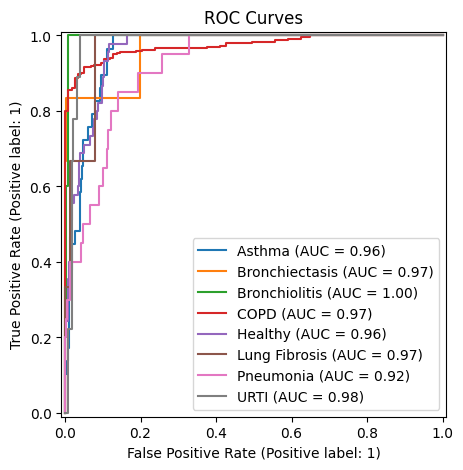

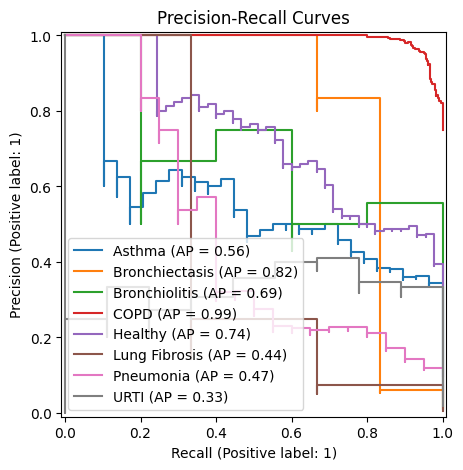

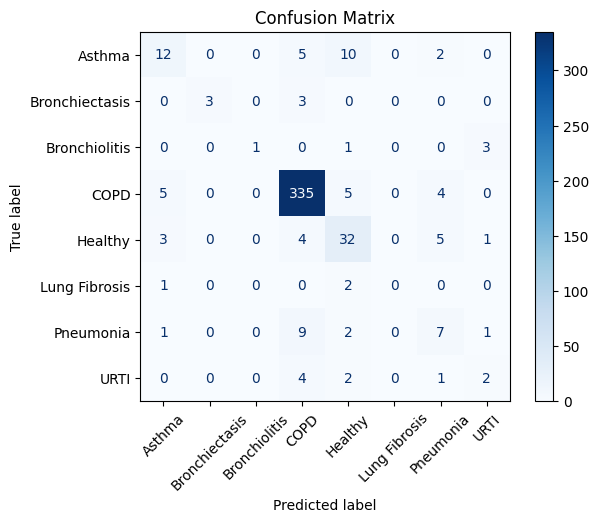

In [7]:
evaluate_model(model)

In [8]:
%tensorboard --logdir {LOGS_FOLDER}